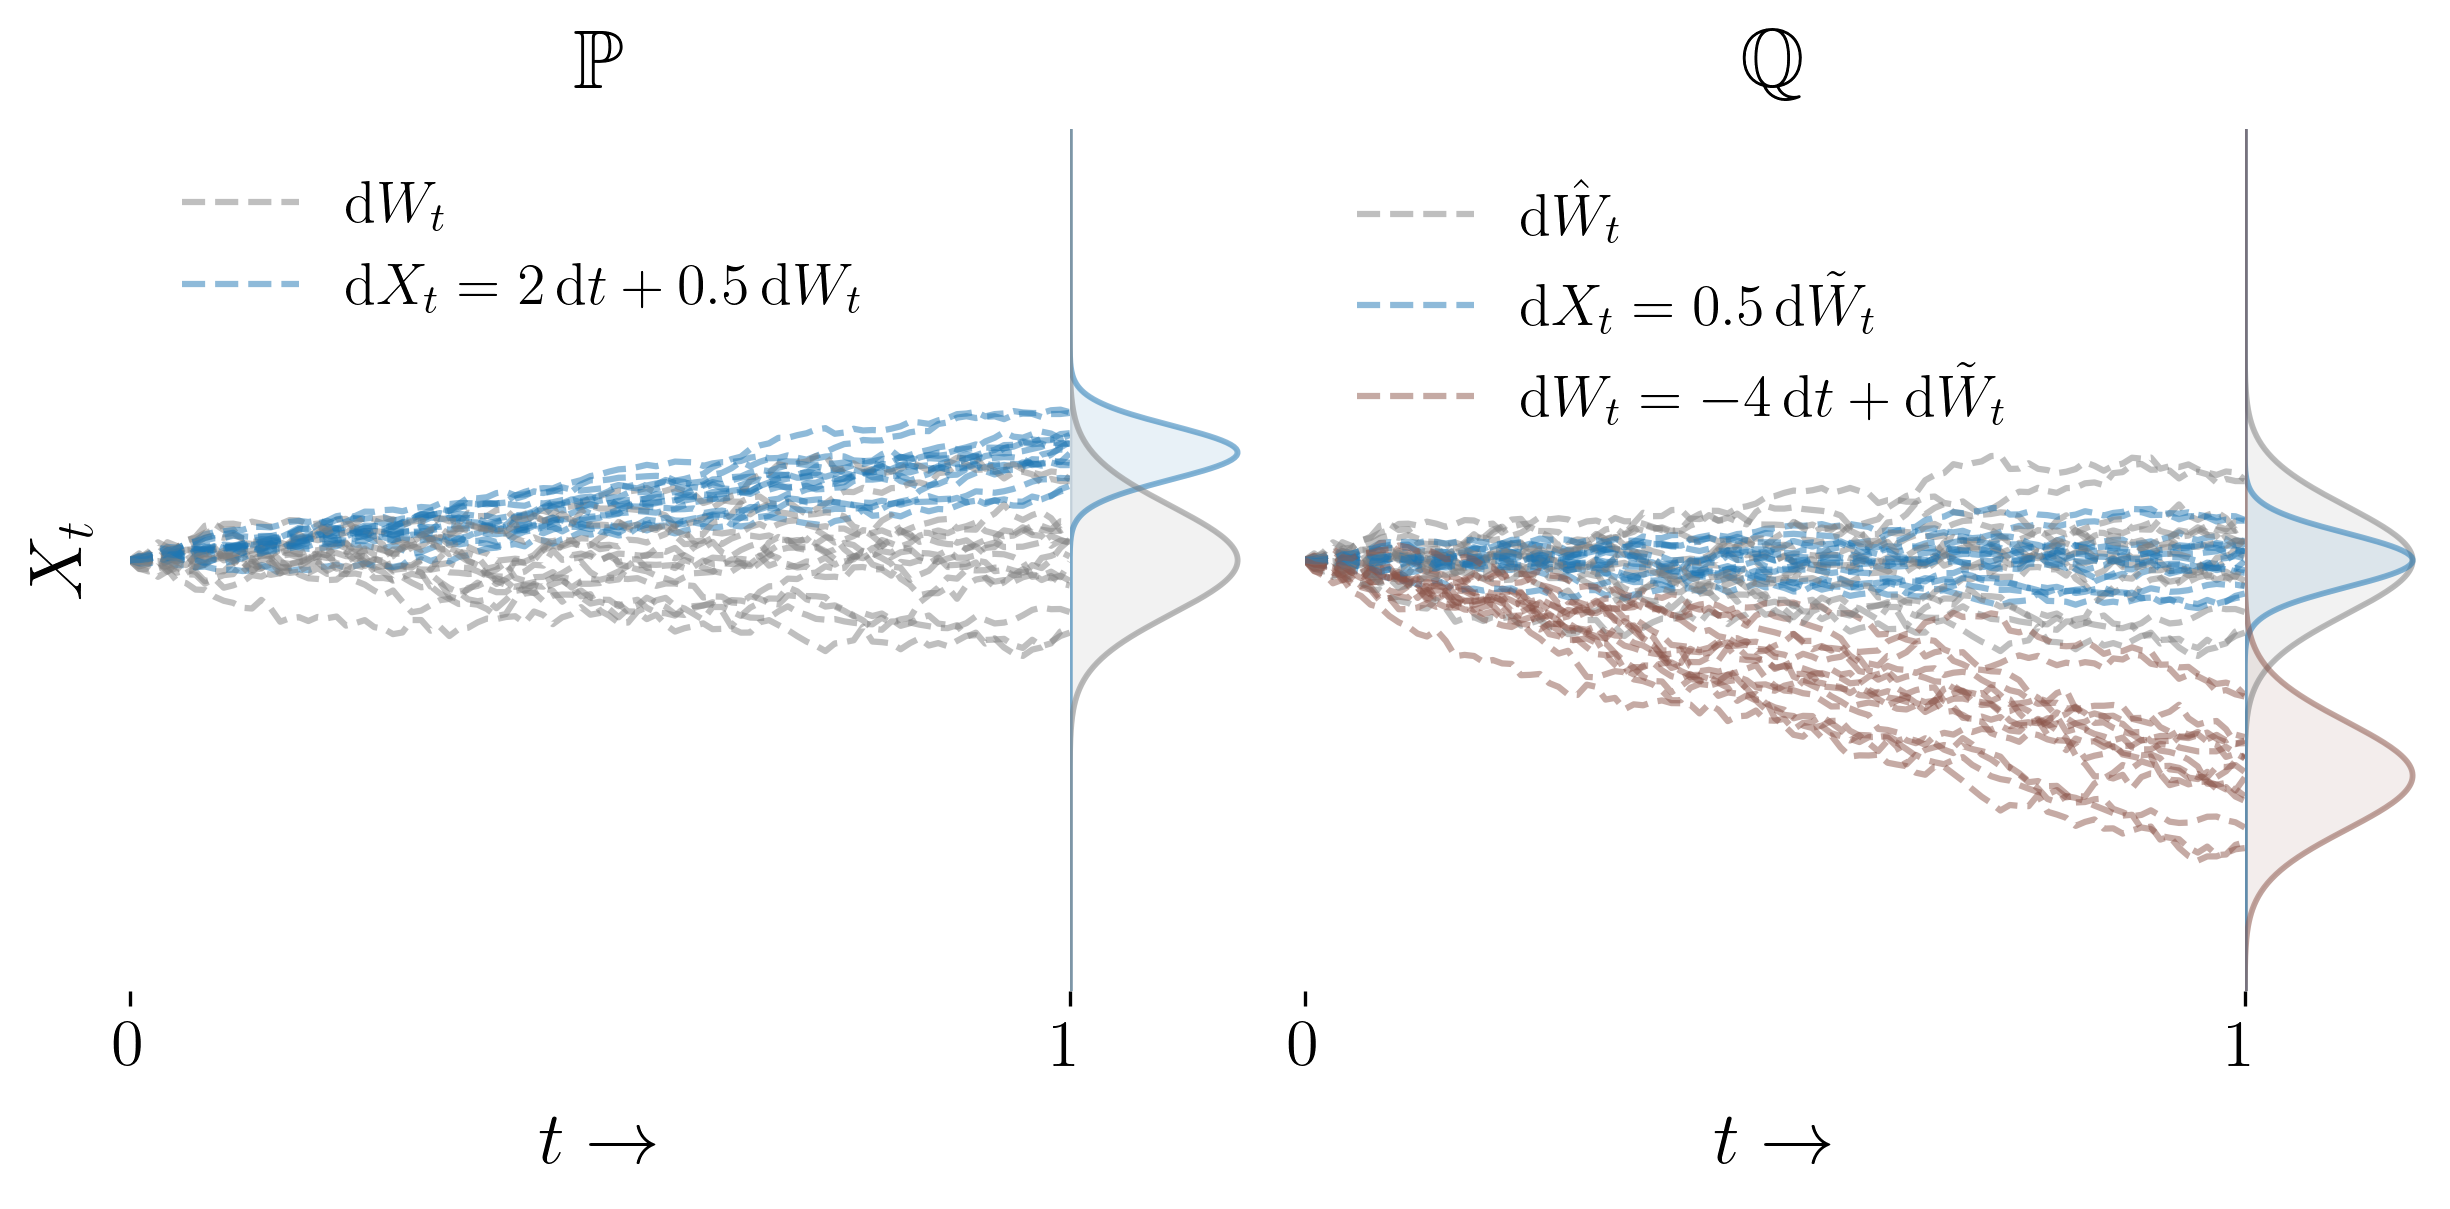

In [ ]:
from pathlib import Path

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

# ------------------------------------------------------------------
# matplotlib / latex setup  (unchanged)
# ------------------------------------------------------------------
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({"text.usetex": True, "font.family": "serif"})
plt.rc("text.latex", preamble=r"\usepackage{amsfonts}\usepackage{amsmath}")

savepath = Path(
    "/Users/shreyaspadhy/Documents/Obsidian Vault/phd-thesis/Chapter3/Figs/"
)

# ------------------------------------------------------------------
# parameters
# ------------------------------------------------------------------
mu_0, sigma_0 = 2, 0.5
T = 10_000
t = np.linspace(0, 1, T)
dt = 1 / T
sns_blue = sns.color_palette("tab10")[0]
sns_brown = sns.color_palette("tab10")[5]
grey = "grey"

# ------------------------------------------------------------------
# figure and axes  --------------------------------------------------
# width_ratios: [main‑left, pdf‑left, main‑right, pdf‑right]
fig = plt.figure(figsize=(8.27, 4.13), dpi=300)  # size in inches
gs = gridspec.GridSpec(
    nrows=1,
    ncols=5,
    width_ratios=[16, 3, 1, 16, 3],  # <─ the 1.5 is *just* empty space
    wspace=0,  # no automatic gaps elsewhere
)

ax_L = fig.add_subplot(gs[0])
pdf_L = fig.add_subplot(gs[1], sharey=ax_L)

fig.add_subplot(gs[2]).axis("off")  # dummy spacer, invisible

# fig.add_subplot(gs[5]).axis("off")           # dummy spacer, invisible

ax_R = fig.add_subplot(gs[3])
pdf_R = fig.add_subplot(gs[4], sharey=ax_R)

# fig.subplots_adjust(left=0.05,   # standard left margin
#                     right=0.985) # <── pull everything 1.5 % away from the edge

# ------------------------------------------------------------------
# simulate sample paths (exactly the same as before)
# ------------------------------------------------------------------
for j in range(15):
    noises = np.random.normal(0, 1, T)

    # left‑grey: Brownian
    X[:] = 0
    for i in range(T - 1):
        X[i + 1] = X[i] + np.sqrt(dt) * noises[i]
    ax_L.plot(
        np.append(t[::100], t[-1]),
        np.append(X[::100], X[-1]),
        label=r"$\mathrm{d}W_t$" if j == 0 else "",
        color="grey",
        ls="--",
        alpha=0.5,
    )

    # left panel: dX = 2 dt + 0.5 dW
    X = np.zeros(T)
    for i in range(T - 1):
        X[i + 1] = X[i] + mu_0 * dt + sigma_0 * np.sqrt(dt) * noises[i]
    ax_L.plot(
        np.append(t[::100], t[-1]),
        np.append(X[::100], X[-1]),
        label=r"$\mathrm{d}X_t = 2\,\mathrm{d}t + 0.5\,\mathrm{d}W_t$"
        if j == 0
        else "",
        color=sns_blue,
        ls="--",
        alpha=0.5,
    )

    # right‑grey: dW̃
    X[:] = 0
    for i in range(T - 1):
        X[i + 1] = X[i] + np.sqrt(dt) * noises[i]
    ax_R.plot(
        np.append(t[::100], t[-1]),
        np.append(X[::100], X[-1]),
        label=r"$\mathrm{d} \hat{W}_t$" if j == 0 else "",
        color="grey",
        ls="--",
        alpha=0.5,
    )

    # right panel: dX = 0.5 dW̃
    X[:] = 0
    for i in range(T - 1):
        X[i + 1] = X[i] + sigma_0 * np.sqrt(dt) * noises[i]
    ax_R.plot(
        np.append(t[::100], t[-1]),
        np.append(X[::100], X[-1]),
        label=r"$\mathrm{d}X_t = 0.5\,\mathrm{d}\tilde{W}_t$" if j == 0 else "",
        color=sns_blue,
        ls="--",
        alpha=0.5,
    )

    # right‑grey: dW = −4 dt + dW̃
    X[:] = 0
    for i in range(T - 1):
        X[i + 1] = X[i] - 4 * dt + np.sqrt(dt) * noises[i]
    ax_R.plot(
        np.append(t[::100], t[-1]),
        np.append(X[::100], X[-1]),
        label=r"$\mathrm{d}W_t = -4\,\mathrm{d}t + \mathrm{d}\tilde{W}_t$"
        if j == 0
        else "",
        color=sns_brown,
        ls="--",
        alpha=0.5,
    )


# ------------------------------------------------------------------
# helper to paint pdf in its own axis
# ------------------------------------------------------------------
def paint_pdf(ax, mus, sigmas, colors, flip=False, strip_width=1.0):
    """
    Draw horizontal Gaussian strips inside *ax*.
    If flip is True, the axis is later inverted so the strip hugs the right edge.
    """
    y = np.linspace(-8, 8, 400)

    for μ, σ, c in zip(mus, sigmas, colors):
        pdf = norm.pdf(y, loc=μ, scale=σ)
        pdf = pdf / pdf.max() * strip_width  # scale to full axis width

        ax.plot(pdf, y, color=c, lw=1.4, alpha=0.5)  # <-- pdf is a vector
        ax.fill_betweenx(y, 0, pdf, color=c, alpha=0.1)

    ax.set_xlim(0, strip_width * 1.05)  # add 5% padding on the right edge
    if flip:
        ax.invert_xaxis()  # mirror the whole axis

    # cosmetics
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)


# paint both density panels
paint_pdf(pdf_L, mus=[2, 0], sigmas=[0.5, 1.0], colors=[sns_blue, "grey"])
paint_pdf(
    pdf_R,
    mus=[0, 0, -4],
    sigmas=[1.0, 0.5, 1.0],
    colors=["grey", sns_blue, sns_brown],
    flip=False,
)  # mirrored, but no shape mismatch

# ------------------------------------------------------------------
# styling for the two trajectory panels
# ------------------------------------------------------------------
for ax, title, ylabel in [
    (ax_L, r"$\mathbb{P}$", "$X_t$"),
    (ax_R, r"$\mathbb{Q}$", ""),
]:
    ax.set_title(title, fontsize=20, pad=10)
    ax.set_xlim([0, 1])
    ax.set_ylim([-8, 8])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticks([0, 1], [0, 1], fontsize=16)
    ax.set_yticks([-8, 0, 8], [-8, 0, 8], fontsize=16)
    ax.set_xlabel(r"$t \rightarrow$", fontsize=18, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=18, labelpad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

pdf_L.set_xticks([])
pdf_R.set_xticks([])
pdf_L.set_yticks([])
pdf_R.set_yticks([])
ax_L.legend(fontsize=14, loc="upper left", frameon=False)
ax_R.legend(fontsize=14, loc="upper left", frameon=False)

plt.tight_layout()

plt.savefig(
    Path(savepath) / "Vector" / "sde_girsanov.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)
plt.savefig(
    Path(savepath) / "Raster" / "sde_girsanov.png",
    format="png",
    transparent=True,
    bbox_inches="tight",
    dpi=400,
)
plt.show()